# Mathematical Model of Hiring

### Project Overview
This project studies recruitment decisions under uncertainty using the Secretary Problem. The goal is to analyze and simulate strategies that maximize the probability of selecting the best candidate when candidates are evaluated sequentially and decisions must be made immediately.

**Key concepts:** probability, optimal stopping, simulation  
**Tools:** Python, NumPy, Monte Carlo simulation
Math Concepts for Developers  
Ina Dimitrova

## Contents
1. Introduction
2. Research Question
3. The Secretary Problem
4. Mathematical Model
5. Simulation
6. Results
7. Limitations
8. Conclusion

In [ ]:
## Introduction

Recruitment requires making decisions under uncertainty. Candidates are interviewed one after another, and organizations must decide whether to continue the search or select a candidate without knowing the future applicants. So, the hiring process is challenging and and strategic.
From a mathematical perspective, this situation can be modeled using the Secretary problem, a classical problem in probability theory that studies how to select the best option from a sequence of candidates. The problem provides a framework for analyzing optimal decision strategies when choices must be made immediately and cannot be reversed.
The goal of the project is to model the hiring process mathematically, analyze the optimal stopping strategy, and validate the theoretical results through simulation. Using Python, we explore how different strategies perform and illustrate why the well-known 37% rule emerges could be a solution for selecting the best candidate


In [1]:
## Research Question

When candidates are evaluated sequentially and decisions must be made immediately, what strategy maximizes the probability of selecting the best candidate?

This project investigates how the recruitment process can be modeled using the Secretary problem and whether the theoretical optimal strategy — observing approximately 37% of candidates before making a selection — leads to better hiring outcomes.

In [ ]:
## The Secretary Problem


The Secretary Problem is a classical problem in probability and decision theory. It describes a situation in which a decision-maker must choose the best option from a sequence of candidates that are evaluated one by one.

In this model, each candidate has a **rank** representing their overall quality. The best candidate has rank 1, the second-best candidate has rank 2, and so on up to \(n\), where \(n\) is the total number of candidates. The interviewer does not know the absolute rank of a candidate but can compare candidates to those already interviewed and determine whether the current candidate is better or not.

The difficulty in this problem is that once a candidate is rejected, they cannot be recalled. So, the decision must be made immediately after each interview, without knowing the quality of future candidates.

The objective is to maximize the probability of selecting the **best candidate overall** (the candidate with rank 1).

This problem leads to an **optimal stopping strategy**: first observe a portion of the candidates without selecting any, and then choose the first candidate who is better than the previously observed.

Mathematically, the optimal strategy is to observe approximately the first:

$$
r \approx \frac{n}{e}
$$

where  

- \(n\) is the total number of candidates  
- \(e\) is Euler's number (\(e \approx 2.718\))  
- \(\lfloor x \rfloor\) denotes the floor function (rounding down to the nearest integer).

### Probability of Success

Using this strategy, the probability of successfully selecting the best candidate approaches

$$
P(\text{success}) \approx \frac{1}{e} \approx 0.37.
$$

This means that even when following the optimal strategy, the best candidate will be selected only about **37% of the time**. This result highlights the difficulty of making optimal decisions when options must be evaluated sequentially and rejected candidates cannot be recalled.

Although the Secretary Problem is a simplified theoretical model, it captures an important aspect of recruitment: decisions often must be made sequentially and under uncertainty. To analyze this process, the next section introduces a mathematical model describing how candidates are represented and how the stopping rule can be applied.


In [ ]:
## Mathematical Model

Assume that there are \( n \) candidates who are interviewed sequentially. The order in which the candidates appear is random. Each candidate has a rank representing their quality, where

$$
1 = \text{best candidate}, \quad n = \text{worst candidate}.
$$

During the interview process, the decision-maker cannot know the true rank of a candidate but can compare the current candidate to those already interviewed.

### Observation Phase

Let \( r \) represent the number of candidates observed without selecting any of them. During this phase, the interviewer simply records the best candidate seen so far.

After the first \( r \) candidates have been rejected, the interviewer selects the first candidate who is better than all previously observed candidates.

### Probability of Success

The goal of the strategy is to maximize the probability of selecting the best candidate overall.

If the best candidate appears after the observation phase and is better than all previously observed candidates, the algorithm will select them.

Mathematical analysis shows that the optimal value of \( r \) is approximately

$$
r \approx \frac{n}{e}
$$

where \( e \approx 2.718 \) is Euler's number.

With this strategy, the probability of selecting the best candidate approaches

$$
P \approx \frac{1}{e} \approx 0.37.
$$

This means that even when using the optimal strategy, the best candidate will be selected about **37% of the time**.


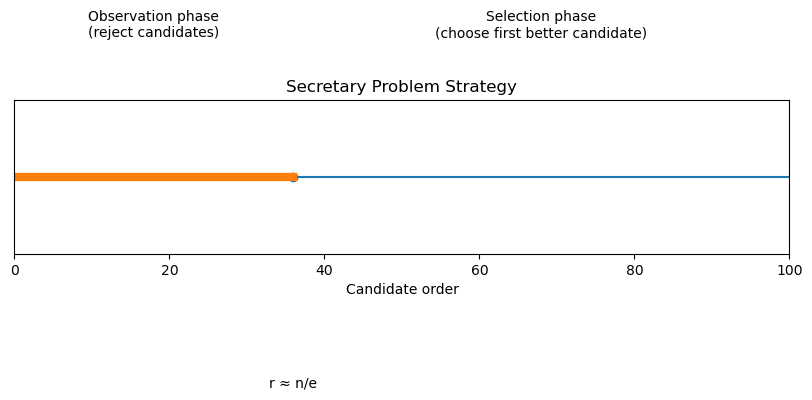

In [1]:
import matplotlib.pyplot as plt

n = 100
r = int(n/2.718)  # approximate n/e

plt.figure(figsize=(10,2))

# timeline
plt.plot([0,n],[0,0])

# observation phase
plt.plot([0,r],[0,0], linewidth=6)

# labels
plt.text(r/2,0.1,"Observation phase\n(reject candidates)", ha='center')
plt.text((r+n)/2,0.1,"Selection phase\n(choose first better candidate)", ha='center')

# markers
plt.scatter([r],[0])
plt.text(r,-0.15,"r ≈ n/e", ha='center')

plt.xlim(0,n)
plt.yticks([])
plt.xlabel("Candidate order")
plt.title("Secretary Problem Strategy")

plt.show()

In [2]:
## Simulation

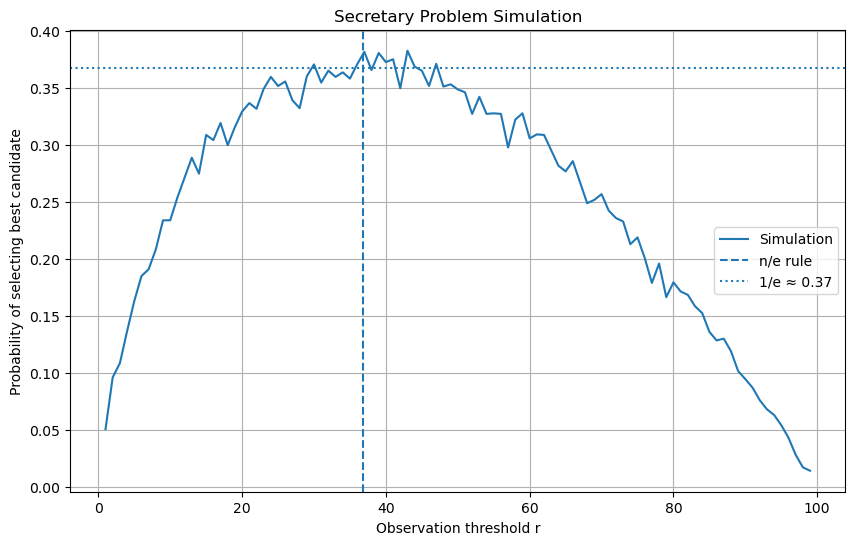

In [4]:
%matplotlib inline
import random
import numpy as np
import matplotlib.pyplot as plt


def secretary_algorithm(n, r):

    candidates = list(range(1, n+1))
    random.shuffle(candidates)

    best_seen = min(candidates[:r])

    for i in range(r, n):
        if candidates[i] < best_seen:
            if candidates[i] == 1:
                return 1
            else:
                return 0

    return 0


def simulate(n, r, trials=2000):

    success = 0

    for _ in range(trials):
        success += secretary_algorithm(n, r)

    return success / trials


n = 100
trials = 2000

results = []

for r in range(1, n):
    prob = simulate(n, r, trials)
    results.append(prob)


plt.figure(figsize=(10,6))

plt.plot(range(1,n), results, label="Simulation")

plt.axvline(n/np.e, linestyle="--", label="n/e rule")
plt.axhline(1/np.e, linestyle=":", label="1/e ≈ 0.37")

plt.xlabel("Observation threshold r")
plt.ylabel("Probability of selecting best candidate")

plt.title("Secretary Problem Simulation")

plt.legend()
plt.grid(True)

plt.show()

In [6]:
## Results

To test how well the hiring strategy works, we ran a simulation based on the Secretary Problem. In the simulation, each candidate is given a rank showing how good they are: rank 1 is the best candidate, and rank n is the worst. The order in which candidates are interviewed is random.
We introduced a trial phase, where the first few candidates are observed but not hired. For each length of this trial phase, the simulation was run many times with different candidate orders. A run is considered successful if the best candidate (rank 1) is eventually selected. The success rate is calculated as the percentage of runs where this happens.
The results show that the chance of picking the best candidate depends a lot on how long the trial phase is.
	If the trial phase is very short, the algorithm tends to hire someone too early, before seeing enough candidates. This often leads to missing the best candidate.
	If the trial phase is too long, many candidates are passed over, including the best one, so the algorithm may never select them.
The simulation shows that the best chance of hiring the top candidate happens when the trial phase is about one-third of all candidates:
$$trial phase≈n/e.$$

For example, if there are 100 candidates, the optimal trial phase is around 36–37 candidates. At this point, the probability of choosing the best candidate is roughly 37%, which matches the theoretical prediction from the Secretary Problem.
Overall, this shows that the strategy works by balancing watching enough candidates to learn who’s best with making a good decision at the right time.

    

In [ ]:
## Limitations

In [ ]:
## Conclusion